# Machine Learning Para Predição de Desempenho de Alunos do 3º/4º do Ensino Médio

## Integrantes
- Ana Caroline Souza Lira
- Daniel Goulart Camacho Gonçalves
- Fernando Giongo
- Theo Luigi
- João Gabriel Lourenço Marques

---
O projeto tem por objetivo prever os níveis Saeb de proficiência em Lingua Portuguesa (LP) ou Matemática (MT) de alunos do 3º e 4º Anos do Ensino Médio. Para isso, utilizaremos classificadores de Aprendizado de Máquina em cima dos microdados do Saeb de 2023 e a biblioteca Pandas do Python.

# Pré-processamento de dados

In [1]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_aluno_original = pd.read_csv('dados/TS_ALUNO_34EM.csv', encoding='latin-1', sep=';')
df_diretor_original = pd.read_csv('dados/TS_DIRETOR.csv', encoding='latin-1', sep=';')
df_escola_original = pd.read_csv('dados/TS_ESCOLA.csv', encoding='latin-1', sep=';')

O próximo passo será definir quais features serão mantidas para análise. Para preservar o escopo do estudo, investigamos o dicionário de dados em busca de variáveis que representassem o contexto socioeconômico familiar, a infraestrutura física das escolas e a capacitação dos professores. Esses fatores foram selecionados primariamente por serem aspectos que, em tese, apresentam grande potencial de influência sobre o desempenho dos alunos. Ao longo do projeto, avaliaremos o comportamento dessas variáveis e sua efetiva relevância com os modelos desenvolvidos.

Nesse momento, também definimos critérios de limpeza dos dados. No conjunto de alunos, foram removidos os registros de estudantes que não compareceram às provas ou que responderam pelo menos três questões do questionário socioeconômico. De forma semelhante, no conjunto de diretores, excluímos os registros daqueles que não preencheram o questionário ou que não eram responsáveis por alunos do 3º ou o 4º ano do Ensino Médio. Por fim, no conjunto de escolas, foram removidas as instituições que não possuíam alunos matriculados nessas séries.

In [2]:
# ================================================================
# Escolhemos a features que temos interesses e as features
# que usaremos para limpar linhas que não tenham dados relevantes
# ================================================================

colunas_de_interesse_aluno = ['ID_ESCOLA', 'ID_ALUNO', 'ID_UF', 'ID_MUNICIPIO', 'ID_AREA', 'IN_PUBLICA', 'ID_SERIE', 'PROFICIENCIA_LP_SAEB',
'PROFICIENCIA_MT_SAEB', 'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03', 'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
'TX_RESP_Q05c', 'TX_RESP_Q06','TX_RESP_Q07a','TX_RESP_Q07b','TX_RESP_Q07c','TX_RESP_Q07d','TX_RESP_Q07e','TX_RESP_Q08','TX_RESP_Q09',
'TX_RESP_Q10a','TX_RESP_Q10b','TX_RESP_Q10c','TX_RESP_Q10d','TX_RESP_Q10e','TX_RESP_Q10f','TX_RESP_Q11a','TX_RESP_Q11b','TX_RESP_Q11c',
'TX_RESP_Q12b','TX_RESP_Q12c','TX_RESP_Q14','TX_RESP_Q15b','TX_RESP_Q16','TX_RESP_Q18','TX_RESP_Q21a',
'TX_RESP_Q21b','TX_RESP_Q21c','TX_RESP_Q21d','TX_RESP_Q21e','TX_RESP_Q23d','TX_RESP_Q24']

remover_aluno = {
    'IN_PRESENCA_LP': 0,                    # Remover alunos que não tenham respondido a prova de língua portuguesa
    'IN_PRESENCA_MT': 0,                    # Remover alunos que não tenham respondido a prova de matemática
    'IN_PROFICIENCIA_LP': 0,                # Remover alunos que não tenham proficiência em língua portuguesa
    'IN_PROFICIENCIA_MT': 0,                # Remover alunos que não tenham proficiência em matemática
    'IN_PREENCHIMENTO_QUESTIONARIO': 0}     # Remover alunos que não preencheram o questionário

colunas_de_interesse_diretor = ['ID_ESCOLA', 'ID_SERIE', 'TX_Q020','TX_Q022','TX_Q032','TX_Q033','TX_Q035',
'TX_Q036','TX_Q056','TX_Q057','TX_Q078','TX_Q079','TX_Q081','TX_Q082','TX_Q083', 'TX_Q085','TX_Q087',
'TX_Q108','TX_Q119','TX_Q129','TX_Q130','TX_Q139','TX_Q191','TX_Q194','TX_Q203','TX_Q205','TX_Q206','TX_Q207',
'TX_Q208','TX_Q209']

remover_diretor = {
    'IN_PREENCHIMENTO_QUESTIONARIO': [0],   # Remover diretores que não preencheram o questionário
    'ID_SERIE': [5, 9, 2]}

colunas_de_interesse_escola = ['ID_ESCOLA','PC_FORMACAO_DOCENTE_MEDIO']

remover_escola = {
    'NU_PRESENTES_EM': 0}                   # Remover escolas que não tenham alunos presentes no ensino médio


# ================================================================
# Aplicaremos as regras de limpeza de dados e selecionaremos as features
# ================================================================

print("\n# ================================================================\n")
df_aluno_limpo = df_aluno_original.copy()
df_diretor_limpo = df_diretor_original.copy()
df_escola_limpo = df_escola_original.copy()

for coluna, valor in remover_aluno.items():
    antes = len(df_aluno_limpo)
    df_aluno_limpo = df_aluno_limpo[df_aluno_limpo[coluna] != valor]
    removidas = antes - len(df_aluno_limpo)

    print(
        f"Alunos: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

for coluna, valor in remover_diretor.items():
    antes = len(df_diretor_limpo)
    df_diretor_limpo = df_diretor_limpo[~df_diretor_limpo[coluna].isin(valor)]
    removidas = antes - len(df_diretor_limpo)

    print(
        f"Diretores: removidas {removidas} linhas "
        f"pela regra: {valor} não estar em {coluna}"
    )

for coluna, valor in remover_escola.items():
    antes = len(df_escola_limpo)
    df_escola_limpo = df_escola_limpo[df_escola_limpo[coluna] != valor]
    removidas = antes - len(df_escola_limpo)

    print(
        f"Escolas: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

df_aluno_limpo = df_aluno_limpo[colunas_de_interesse_aluno]
df_diretor_limpo = df_diretor_limpo[colunas_de_interesse_diretor]
df_escola_limpo = df_escola_limpo[colunas_de_interesse_escola]

print("\n# ================================================================\n")
print(f'Alunos: {len(df_aluno_limpo)} linhas')
print(f'Diretores: {len(df_diretor_limpo)} linhas')
print(f'Escolas: {len(df_escola_limpo)} linhas')
print("\n# ================================================================\n")

# Quantidade de linhas removidas do dataset original
print(f'Alunos: {len(df_aluno_original) - len(df_aluno_limpo)} linhas removidas do dataset original -> {(len(df_aluno_limpo))/len(df_aluno_original)*100:.2f}% linhas restantes')
print(f'Diretores: {len(df_diretor_original) - len(df_diretor_limpo)} linhas removidas do dataset original -> {(len(df_diretor_limpo))/len(df_diretor_original)*100:.2f}% linhas restantes')
print(f'Escolas: {len(df_escola_original) - len(df_escola_limpo)} linhas removidas do dataset original -> {(len(df_escola_limpo))/len(df_escola_original)*100:.2f}% linhas restantes')

print("\n# ================================================================\n")


# ================================================================

Alunos: removidas 562414 linhas pela regra: IN_PRESENCA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PRESENCA_MT != 0
Alunos: removidas 2966 linhas pela regra: IN_PROFICIENCIA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PROFICIENCIA_MT != 0
Alunos: removidas 11509 linhas pela regra: IN_PREENCHIMENTO_QUESTIONARIO != 0
Diretores: removidas 17304 linhas pela regra: [0] não estar em IN_PREENCHIMENTO_QUESTIONARIO
Diretores: removidas 72208 linhas pela regra: [5, 9, 2] não estar em ID_SERIE
Escolas: removidas 122 linhas pela regra: NU_PRESENTES_EM != 0

# ================================================================

Alunos: 1514448 linhas
Diretores: 17577 linhas
Escolas: 70029 linhas

# ================================================================

Alunos: 576889 linhas removidas do dataset original -> 72.42% linhas restantes
Diretores: 89512 linhas removidas do dataset original -> 16.41% linhas restantes


In [3]:
# ================================================================
# Podemos ter problemas ao unificar as tabelas se houver escolas
# com o mesmo ID e multiplos diretores
# ================================================================

print("\n# ================================================================\n")
print(f"Alunos em mais de uma escola: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")
print(f"Alunos duplicados: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")


print(f"Escolas com ID_ESCOLA duplicados: {df_escola_limpo['ID_ESCOLA'].duplicated().sum()}")

escolas_com_diretores_duplicados = (
    df_diretor_limpo['ID_ESCOLA']
    .value_counts()
    .loc[lambda x: x > 1]
)

escolas_sem_diretores = (
    df_escola_limpo['ID_ESCOLA']
    .loc[~df_escola_limpo['ID_ESCOLA'].isin(df_diretor_limpo['ID_ESCOLA'])]
)

print(f'Escolas com mais de um diretor: {len(escolas_com_diretores_duplicados)}')
print("\n# ================================================================\n")


# ================================================================

Alunos em mais de uma escola: 0
Alunos duplicados: 0
Escolas com ID_ESCOLA duplicados: 0
Escolas com mais de um diretor: 723

# ================================================================



In [4]:
# ================================================================
# Vamos tratar as Features transformando de categóricas para numéricas quando possivel
# ================================================================

colunas_diretor_numericas = [
    'TX_Q020',
    'TX_Q022'
]

colunas_diretor_ordinais_AD = [
    'TX_Q056',
    'TX_Q057',
    'TX_Q108'
]

colunas_diretor_ordinais_AE = [
    'TX_Q032',
    'TX_Q033',
    'TX_Q035',
    'TX_Q036',
    'TX_Q191'
]

colunas_diretor_booleanas = [
    'TX_Q078', 'TX_Q079', 'TX_Q081', 'TX_Q082',
    'TX_Q083', 'TX_Q085', 'TX_Q087', 'TX_Q119',
    'TX_Q129', 'TX_Q130', 'TX_Q139', 'TX_Q194',
    'TX_Q203', 'TX_Q205', 'TX_Q206', 'TX_Q207',
    'TX_Q208', 'TX_Q209'
]

colunas_aluno_booleanas = [
    'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c',
    'TX_RESP_Q07d', 'TX_RESP_Q07e',
    'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c',
    'TX_RESP_Q15b'
]

colunas_aluno_booleanas_ABC = [
]

colunas_aluno_ordinais_AD = [
    'TX_RESP_Q23d'
]

colunas_aluno_categoricas = [
    'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03',
    'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
    'TX_RESP_Q05c', 'TX_RESP_Q06', 'TX_RESP_Q08',
    'TX_RESP_Q09', 'TX_RESP_Q10a', 'TX_RESP_Q10b',
    'TX_RESP_Q10c', 'TX_RESP_Q10d', 'TX_RESP_Q10e',
    'TX_RESP_Q10f', 'TX_RESP_Q12b', 'TX_RESP_Q12c',
    'TX_RESP_Q14', 'TX_RESP_Q16',
    'TX_RESP_Q18', 'TX_RESP_Q21a', 'TX_RESP_Q21b',
    'TX_RESP_Q21c', 'TX_RESP_Q21d', 'TX_RESP_Q21e',
    'TX_RESP_Q24'
]


# ================================================================
# Mapeamentos normalizados [0,1]
# ================================================================

mapa_AD = {
    'A': 0 / 3,
    'B': 1 / 3,
    'C': 2 / 3,
    'D': 3 / 3
}

mapa_AE = {
    'A': 0 / 4,
    'B': 1 / 4,
    'C': 2 / 4,
    'D': 3 / 4,
    'E': 4 / 4
}

mapa_bool = {
    'A': 0.0,
    'B': 1.0
}

mapa_bool_ABC = {
    'A': 0.0,
    'B': 1.0,
    'C': 1.0
}

valores_invalidos = ['*', '.', 'F', '']

# ================================================================
# Conversão das respostas dos diretores
# ================================================================

for col in colunas_diretor_ordinais_AD:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AD)
            .astype('float32')
        )

for col in colunas_diretor_ordinais_AE:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AE)
            .astype('float32')
        )

for col in colunas_diretor_booleanas:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_categoricas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
        )

for col in colunas_aluno_booleanas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_booleanas_ABC:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool_ABC)
            .astype('float32')
        )

for col in colunas_aluno_ordinais_AD:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_AD)
            .astype('float32')
        )

df_aluno_limpo['ID_AREA'] = (
    df_aluno_limpo['ID_AREA']
    .replace({
        1: 0,
        2: 1,
    })
    .astype('float32')
)

df_aluno_limpo['ID_UF'] = df_aluno_limpo['ID_UF'].astype('int8')
df_aluno_limpo['ID_MUNICIPIO'] = df_aluno_limpo['ID_MUNICIPIO'].astype('int32')

# Cada linha restante possui um diretor válido
df_diretor_limpo['POSSUI_DIRETOR'] = np.int8(1)

print("\n# ================================================================\n")
print('Registros duplicados de (ID_ESCOLA, ID_SERIE):',df_diretor_limpo.duplicated(subset=['ID_ESCOLA', 'ID_SERIE']).sum())

# ================================================================
# Estatísticas
# ================================================================

pares_aluno = (
    df_aluno_limpo[['ID_ESCOLA', 'ID_SERIE']]
    .drop_duplicates()
)

pares_diretor = (
    df_diretor_limpo[['ID_ESCOLA', 'ID_SERIE']]
)

pares_com_diretor = (
    pares_aluno.merge(
        pares_diretor,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left',
        indicator=True
    )
)

qtd_com = (pares_com_diretor['_merge'] == 'both').sum()
qtd_sem = (pares_com_diretor['_merge'] == 'left_only').sum()

print(
    f'Pares escola-série com diretor: '
    f'{qtd_com:,} -> '
    f'{100*qtd_com/len(pares_com_diretor):.2f}%'
)

print(
    f'Pares escola-série sem diretor: '
    f'{qtd_sem:,} -> '
    f'{100*qtd_sem/len(pares_com_diretor):.2f}%'
)

# ================================================================
# Merge final
# ================================================================

df_diretor_limpo_copy = df_diretor_limpo.copy()
df_escola_limpo_copy = df_escola_limpo.copy()

df_unificado = (
    df_aluno_limpo
    .merge(
        df_diretor_limpo_copy,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left'
    )
    .merge(
        df_escola_limpo_copy,
        on='ID_ESCOLA',
        how='left'
    )
)

# Escolas/séries sem diretor recebem 0
df_unificado['POSSUI_DIRETOR'] = (
    df_unificado['POSSUI_DIRETOR']
    .fillna(0)
    .astype(np.int8)
)

registros_com = int(df_unificado['POSSUI_DIRETOR'].sum())
registros_sem = len(df_unificado) - registros_com

pct_com = 100 * registros_com / len(df_unificado)
pct_sem = 100 - pct_com

print(
    f'Registros com diretor: '
    f'{registros_com:,} -> {pct_com:.2f}%'
)

print(
    f'Registros sem diretor: '
    f'{registros_sem:,} -> {pct_sem:.2f}%'
)

print(f'Linhas finais: {len(df_unificado):,}')
print("\n# ================================================================\n")


# ================================================================

Registros duplicados de (ID_ESCOLA, ID_SERIE): 0
Pares escola-série com diretor: 17,424 -> 82.82%
Pares escola-série sem diretor: 3,615 -> 17.18%
Registros com diretor: 1,248,091 -> 82.41%
Registros sem diretor: 266,357 -> 17.59%
Linhas finais: 1,514,448

# ================================================================



In [5]:
# ================================================================
# Adicionando a classificação de nível de acordo com a escala SAEB
# ================================================================
df_final = df_unificado.copy()

df_final = df_final[df_final['PROFICIENCIA_LP_SAEB'] >= 225]
df_final = df_final[df_final['PROFICIENCIA_MT_SAEB'] >= 225]

def classificar_nivel_LP(nota_proficiencia):
    if nota_proficiencia < 300:
        return 1
    elif 300 <= nota_proficiencia < 350:
        return 2
    elif nota_proficiencia >= 350:
        return 3

def classificar_nivel_MT(nota_proficiencia):
    if nota_proficiencia < 300:
        return 1
    elif 300 <= nota_proficiencia < 375:
        return 2
    elif nota_proficiencia >= 375:
        return 3



# Adicionando os níveis de proficiência de cada aluno e removendo as colunas originais de proficiência
df_final['NIVEL_LP'] = df_final['PROFICIENCIA_LP_SAEB'].apply(classificar_nivel_LP)
df_final['NIVEL_MT'] = df_final['PROFICIENCIA_MT_SAEB'].apply(classificar_nivel_MT)
df_final = df_final.drop(columns=['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB'])

df_final = df_final[(df_final['NIVEL_LP'] != 0) & (df_final['NIVEL_MT'] != 0)]

df_final.tail(20)

,ID_ESCOLA,ID_ALUNO,ID_UF,ID_MUNICIPIO,ID_AREA,IN_PUBLICA,ID_SERIE,TX_RESP_Q01,TX_RESP_Q02,TX_RESP_Q03,...,TX_Q203,TX_Q205,TX_Q206,TX_Q207,TX_Q208,TX_Q209,POSSUI_DIRETOR,PC_FORMACAO_DOCENTE_MEDIO,NIVEL_LP,NIVEL_MT
1514419,61470349,56425817,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1
1514421,61470349,56425947,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,1
1514424,61470349,56425953,53,6327738,0.0,1,12,B,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1
1514429,61470349,56414487,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,1
1514430,61470349,56414488,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1
1514431,61470349,56414489,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,2
1514432,61470349,56414490,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,2
1514433,61470349,56414493,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,1
1514434,61470349,56414494,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,2
1514436,61470349,56415763,53,6327738,0.0,1,12,A,D,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1


#### Análise Exploratória dos dados pré-processados

Esta análise visa compreender a estrutura, distribuição e características dos dados pré-processados para o projeto de previsão de proficiência em Língua Portuguesa e Matemática. Vamos examinar:

- **Estrutura geral**: dimensões, tipos de dados, valores ausentes
- **Variáveis alvo**: distribuição dos níveis de proficiência
- **Features numéricas**: estatísticas e distribuições
- **Features categóricas**: frequências e proporções
- **Correlações**: relações entre variáveis e as variáveis alvo

In [24]:
# 1. VISÃO GERAL DOS DADOS


print("=" * 80)
print("VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS")
print("=" * 80)

print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")
print(f"   Colunas (features): {df_final.shape[1]}")

print("-" * 60)

print("\n◉ Tipos de Dados:")
print(df_final.dtypes.value_counts())

print("-" * 60)

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("Nenhum valor ausente detectado!")

VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS

◉ Dimensões do Dataset:
   Linhas (amostras): 286,993
   Colunas (features): 76
------------------------------------------------------------

◉ Tipos de Dados:
float32    37
str        27
int64       6
float64     3
int8        2
int32       1
Name: count, dtype: int64
------------------------------------------------------------

◉ Valores Ausentes (Missing Values):
Nenhum valor ausente detectado!


*Análise das Variáveis Alvo*

As variáveis alvo representam os níveis de proficiência dos alunos de acordo com a escala SAEB:
- **NIVEL_LP**: Nível de Proficiência em Língua Portuguesa (0-8)
- **NIVEL_MT**: Nível de Proficiência em Matemática (0-10)

In [25]:
print("\n" + "=" * 80)
print("ANÁLISE DAS VARIÁVEIS ALVO")
print("=" * 80)

# Verificar se as colunas de nível existem
if 'NIVEL_LP' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_LP (Língua Portuguesa):")
    nivel_lp_counts = df_final['NIVEL_LP'].value_counts().sort_index()
    nivel_lp_pct = (nivel_lp_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_lp_counts.items():
        pct = nivel_lp_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_lp_counts.index.min()}, Máx={nivel_lp_counts.index.max()}, Moda={df_final['NIVEL_LP'].mode().values[0]}")

if 'NIVEL_MT' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_MT (Matemática):")
    nivel_mt_counts = df_final['NIVEL_MT'].value_counts().sort_index()
    nivel_mt_pct = (nivel_mt_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_mt_counts.items():
        pct = nivel_mt_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_mt_counts.index.min()}, Máx={nivel_mt_counts.index.max()}, Moda={df_final['NIVEL_MT'].mode().values[0]}")

# Analisar o balanceamento das classes
if 'NIVEL_LP' in df_final.columns and 'NIVEL_MT' in df_final.columns:
    print("\n◉  Balanceamento das Classes:")
    lp_entropy = -((nivel_lp_pct / 100) * np.log2(nivel_lp_pct / 100 + 1e-10)).sum()
    mt_entropy = -((nivel_mt_pct / 100) * np.log2(nivel_mt_pct / 100 + 1e-10)).sum()
    print(f"   Entropia NIVEL_LP (0=uniforme, máx≈{np.log2(len(nivel_lp_counts)):.2f}): {lp_entropy:.3f}")
    print(f"   Entropia NIVEL_MT (0=uniforme, máx≈{np.log2(len(nivel_mt_counts)):.2f}): {mt_entropy:.3f}")



ANÁLISE DAS VARIÁVEIS ALVO

◉ Distribuição - NIVEL_LP (Língua Portuguesa):
   Nível  1:    143,186 ( 49.89%) ████████████████████████
   Nível  2:    115,727 ( 40.32%) ████████████████████
   Nível  3:     28,080 (  9.78%) ████

   Estatísticas: Mín=1, Máx=3, Moda=1

◉ Distribuição - NIVEL_MT (Matemática):
   Nível  1:    177,090 ( 61.71%) ██████████████████████████████
   Nível  2:     98,846 ( 34.44%) █████████████████
   Nível  3:     11,057 (  3.85%) █

   Estatísticas: Mín=1, Máx=3, Moda=1

◉  Balanceamento das Classes:
   Entropia NIVEL_LP (0=uniforme, máx≈1.58): 1.357
   Entropia NIVEL_MT (0=uniforme, máx≈1.58): 1.140


*Features Numéricas*


Vamos analisar as distribuições e estatísticas das variáveis contínuas e discretas.

In [26]:
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DAS FEATURES")
print("=" * 80)

# Identificar colunas numéricas e categóricas
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_final.select_dtypes(include=['object', 'string']).columns.tolist()

# Remover colunas de ID e as variáveis alvo da análise
cols_para_ignorar = ['ID_ALUNO', 'ID_ESCOLA', 'ID_UF', 'ID_AREA', 'ID_SERIE', 'NIVEL_LP', 'NIVEL_MT']
numeric_cols = [col for col in numeric_cols if col not in cols_para_ignorar]

print(f"\n◉ Features Numéricas: {len(numeric_cols)}")
if numeric_cols:
    print(f"   {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    
    # Estatísticas das features numéricas
    stats = df_final[numeric_cols].describe().T
    stats['missing_%'] = (df_final[numeric_cols].isnull().sum() / len(df_final) * 100).values
    
    print("\n   Resumo Estatístico:")
    print(f"   {'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Missing':>8}")
    print("   " + "-" * 80)
    for col in numeric_cols[:15]:  # Mostrar apenas as primeiras 15
        mean_val = df_final[col].mean()
        std_val = df_final[col].std()
        min_val = df_final[col].min()
        max_val = df_final[col].max()
        missing_pct = (df_final[col].isnull().sum() / len(df_final) * 100)
        print(f"   {col:<30} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f} {missing_pct:>7.2f}%")

print(f"\n◉ Features Categóricas: {len(categorical_cols)}")
if categorical_cols:
    print(f"   {categorical_cols}")
    
    print("\n   Contagens de Valores Únicos:")
    for col in categorical_cols[:5]:  # Mostrar apenas as primeiras 5
        unique_count = df_final[col].nunique()
        missing_count = df_final[col].isnull().sum()
        print(f"   {col:<30}: {unique_count:>5} valores únicos, {missing_count:>6} ausentes")


ANÁLISE ESTATÍSTICA DAS FEATURES

◉ Features Numéricas: 42
   ['ID_MUNICIPIO', 'IN_PUBLICA', 'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c', 'TX_RESP_Q07d', 'TX_RESP_Q07e', 'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c']...

   Resumo Estatístico:
   Feature                              Mean        Std        Min        Max  Missing
   --------------------------------------------------------------------------------
   ID_MUNICIPIO                   6324930.61    1533.80 6322170.00 6327738.00    0.00%
   IN_PUBLICA                           1.00       0.00       1.00       1.00    0.00%
   TX_RESP_Q07a                         0.88       0.33       0.00       1.00    0.00%
   TX_RESP_Q07b                         0.71       0.45       0.00       1.00    0.00%
   TX_RESP_Q07c                         0.11       0.32       0.00       1.00    0.00%
   TX_RESP_Q07d                         0.06       0.24       0.00       1.00    0.00%
   TX_RESP_Q07e                         0.68       0.47   

*Visualização das variáveis alvo*

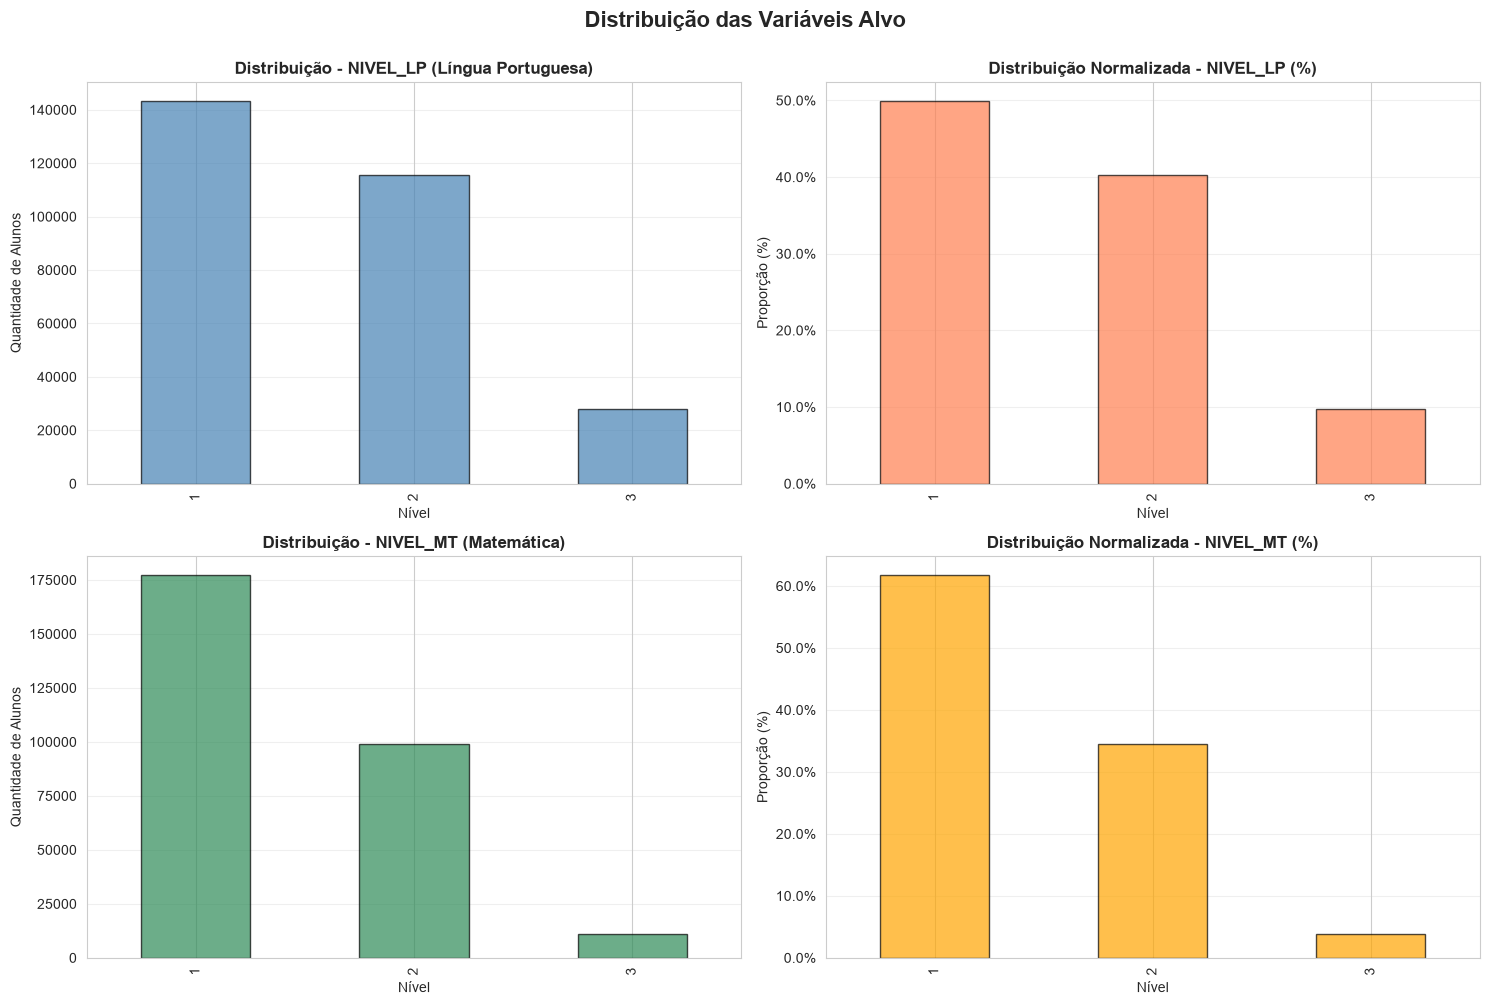

In [27]:
# Configurar estilo do seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Criar subplots para as distribuições das variáveis alvo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição das Variáveis Alvo', fontsize=16, fontweight='bold', y=1.00)

if 'NIVEL_LP' in df_final.columns:
    # Histograma - NIVEL_LP
    ax1 = axes[0, 0]
    df_final['NIVEL_LP'].value_counts().sort_index().plot(
        kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7
    )
    ax1.set_title('Distribuição - NIVEL_LP (Língua Portuguesa)', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Nível')
    ax1.set_ylabel('Quantidade de Alunos')
    ax1.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_LP
    ax2 = axes[0, 1]
    df_final['NIVEL_LP'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax2, color='coral', edgecolor='black', alpha=0.7
    )
    ax2.set_title('Distribuição Normalizada - NIVEL_LP (%)', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Nível')
    ax2.set_ylabel('Proporção (%)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax2.grid(axis='y', alpha=0.3)

if 'NIVEL_MT' in df_final.columns:
    # Histograma - NIVEL_MT
    ax3 = axes[1, 0]
    df_final['NIVEL_MT'].value_counts().sort_index().plot(
        kind='bar', ax=ax3, color='seagreen', edgecolor='black', alpha=0.7
    )
    ax3.set_title('Distribuição - NIVEL_MT (Matemática)', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Nível')
    ax3.set_ylabel('Quantidade de Alunos')
    ax3.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_MT
    ax4 = axes[1, 1]
    df_final['NIVEL_MT'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax4, color='orange', edgecolor='black', alpha=0.7
    )
    ax4.set_title('Distribuição Normalizada - NIVEL_MT (%)', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Nível')
    ax4.set_ylabel('Proporção (%)')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


*Análise de correlações*

Vamos examinar as correlações entre as features numéricas e as variáveis alvo.

In [28]:
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÕES")
print("=" * 80)

# Calcular correlações para variáveis numéricas
numeric_cols_all = df_final.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlação
corr_matrix = df_final[numeric_cols_all].corr()

# Correlações com NIVEL_LP
if 'NIVEL_LP' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_LP:")
    corr_lp = corr_matrix['NIVEL_LP'].drop('NIVEL_LP').sort_values(ascending=False)
    corr_lp = corr_lp[corr_lp.index != 'NIVEL_MT']  # Remover correlação com MT
    corr_lp = corr_lp[~corr_lp.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_lp.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlações com NIVEL_MT
if 'NIVEL_MT' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_MT:")
    corr_mt = corr_matrix['NIVEL_MT'].drop('NIVEL_MT').sort_values(ascending=False)
    corr_mt = corr_mt[corr_mt.index != 'NIVEL_LP']  # Remover correlação com LP
    corr_mt = corr_mt[~corr_mt.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_mt.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlação entre as variáveis alvo
if 'NIVEL_LP' in corr_matrix.columns and 'NIVEL_MT' in corr_matrix.columns:
    corr_lp_mt = corr_matrix.loc['NIVEL_LP', 'NIVEL_MT']
    print(f"\n◉ Correlação entre NIVEL_LP e NIVEL_MT: {corr_lp_mt:.4f}")
    if corr_lp_mt > 0.7:
        print("   -  Correlação forte: os níveis de proficiência em LP e MT estão altamente relacionados")
    elif corr_lp_mt > 0.3:
        print("   -  Correlação moderada: existe relação entre LP e MT")
    else:
        print("   -  Correlação fraca: LP e MT são relativamente independentes")



ANÁLISE DE CORRELAÇÕES

◉ Top 10 Features com maior Correlação com NIVEL_LP:
   Feature                          Correlação
   ---------------------------------------------
    1. TX_Q035                           0.0731
    2. TX_RESP_Q11a                      0.0681
    3. TX_RESP_Q11b                      0.0669
    4. PC_FORMACAO_DOCENTE_MEDIO         0.0620
    5. TX_RESP_Q07a                      0.0525
    6. TX_Q108                           0.0524
    7. TX_Q119                           0.0520
    8. TX_RESP_Q15b                      0.0479
    9. TX_Q194                           0.0450
   10. TX_Q036                           0.0407

◉ Top 10 Features com maior Correlação com NIVEL_MT:
   Feature                          Correlação
   ---------------------------------------------
    1. TX_Q119                           0.0771
    2. TX_Q035                           0.0674
    3. TX_Q108                           0.0571
    4. TX_RESP_Q07a                      0.0536
    

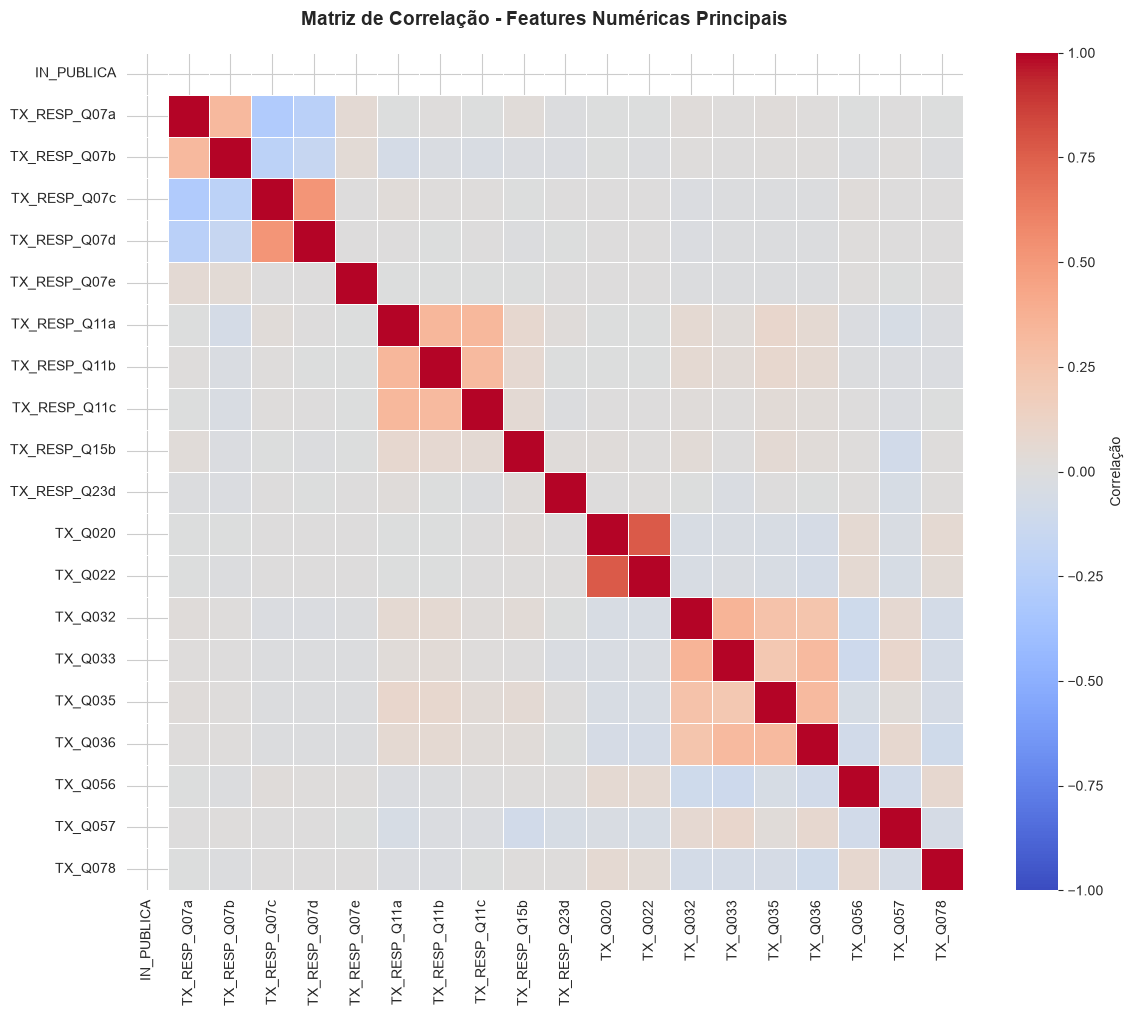

In [29]:
# Visualizar matriz de correlação (primeiras features)
if 'NIVEL_LP' in df_final.columns or 'NIVEL_MT' in df_final.columns:
    # Selecionar apenas as colunas numéricas relevantes (não IDs)
    cols_para_corr = [col for col in numeric_cols_all if not col.startswith('ID_')][:20]
    
    plt.figure(figsize=(12, 10))
    corr_subset = df_final[cols_para_corr].corr()
    
    sns.heatmap(
        corr_subset,
        annot=False,
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação'},
        vmin=-1, vmax=1
    )
    
    plt.title('Matriz de Correlação - Features Numéricas Principais', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

*Principais características do dataset*

In [30]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("=" * 80)

# Resumo geral
print("\n◉ DATASET SUMMARY:")
print(f"   • Total de amostras: {len(df_final):,}")
print(f"   • Total de features: {len(df_final.columns)}")
print(f"   • Features numéricas: {len(numeric_cols_all)}")
print(f"   • Features categóricas: {len(categorical_cols)}")

# Avaliar completude dos dados
missing_percentage = (df_final.isnull().sum().sum() / (len(df_final) * len(df_final.columns))) * 100
print("\n◉ QUALIDADE DOS DADOS:")
print(f"   • Completude geral: {100 - missing_percentage:.2f}%")
print(f"   • Dados ausentes: {missing_percentage:.2f}%")

if missing_percentage < 5:
    print("Qualidade Excelente! Menos de 5% de dados ausentes")
elif missing_percentage < 20:
    print("Qualidade Boa. Será necessário imputação de dados")
else:
    print("Atenção: Significativa quantidade de dados ausentes")

# Análise das variáveis alvo
print("\n◉ VARIÁVEIS ALVO:")
if 'NIVEL_LP' in df_final.columns:
    unique_lp = df_final['NIVEL_LP'].nunique()
    print(f"   • NIVEL_LP: {unique_lp} classes (Nível 0-8)")
    
    # Verificar balanceamento
    lp_counts = df_final['NIVEL_LP'].value_counts()
    lp_ratio = lp_counts.max() / lp_counts.min()
    if lp_ratio < 3:
        print(f"Balanceamento: Bom (proporção máx/min = {lp_ratio:.2f})")
    elif lp_ratio < 10:
        print(f"Balanceamento: Moderado (proporção máx/min = {lp_ratio:.2f})")
    else:
        print(f"Balanceamento: Desbalanceado (proporção máx/min = {lp_ratio:.2f})")

if 'NIVEL_MT' in df_final.columns:
    unique_mt = df_final['NIVEL_MT'].nunique()
    print(f"   • NIVEL_MT: {unique_mt} classes (Nível 0-10)")
    
    # Verificar balanceamento
    mt_counts = df_final['NIVEL_MT'].value_counts()
    mt_ratio = mt_counts.max() / mt_counts.min()
    if mt_ratio < 3:
        print(f" Balanceamento: Bom (proporção máx/min = {mt_ratio:.2f})")
    elif mt_ratio < 10:
        print(f"Balanceamento: Moderado (proporção máx/min = {mt_ratio:.2f})")
    else:
        print(f"Balanceamento: Desbalanceado (proporção máx/min = {mt_ratio:.2f})")



RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

◉ DATASET SUMMARY:
   • Total de amostras: 286,993
   • Total de features: 76
   • Features numéricas: 49
   • Features categóricas: 27

◉ QUALIDADE DOS DADOS:
   • Completude geral: 100.00%
   • Dados ausentes: 0.00%
Qualidade Excelente! Menos de 5% de dados ausentes

◉ VARIÁVEIS ALVO:
   • NIVEL_LP: 3 classes (Nível 0-8)
Balanceamento: Moderado (proporção máx/min = 5.10)
   • NIVEL_MT: 3 classes (Nível 0-10)
Balanceamento: Desbalanceado (proporção máx/min = 16.02)


*Todas as linhas com pelo menos um valor ausente de instância para alguma feature foi removida, de maneira a diminuir o tamanho do dataset e termos dados mais completos.*

In [6]:
from collections import Counter

# Limpar linhas com nulos
df_final = df_final.dropna()

print(Counter(df_final['NIVEL_LP']))
print(Counter(df_final['NIVEL_MT']))

Counter({1: 143186, 2: 115727, 3: 28080})
Counter({1: 177090, 2: 98846, 3: 11057})


In [ ]:
# ==========================================
# Preparação dos Dados para Treinamento e Teste
# ==========================================

df_treino = df_final.copy()

# Removendo IDs e variáveis alvo do conjunto do treino
cols_id = ['ID_ESCOLA', 'ID_ALUNO', 'ID_MUNICIPIO']
targets = ['NIVEL_LP', 'NIVEL_MT']
X = df_treino.drop(columns=cols_id + targets).copy()
y_lp = df_treino['NIVEL_LP']
y_mt = df_treino['NIVEL_MT']

# Conversão de colunas categóricas para numéricas
cols_nominal = ['TX_RESP_Q01', 'TX_RESP_Q03', 'TX_RESP_Q04']
cols_ordinal = [
    c for c in X.columnsd
    if c.startswith('TX_')
    and c not in cols_nominal
    and X[c].dtype == 'object'
]

mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'G': 5, 'H': 6, 'I': 7}
X[cols_ordinal] = X[cols_ordinal].replace(mapping)



# Treinamento dos modelos

### Modelo 1: Regressão Logística

##### Construção, treinamento e métricas

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# Realizando one-hot enconding
X = pd.get_dummies(X, columns=cols_nominal, drop_first=True)
X = pd.get_dummies(X, drop_first=True)


modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', modelo_log)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def rodar_modelo(nome, y):

    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Cross Validation
    # ==================================================

    cv_results = cross_validate(
        pipeline_log,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:   {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
    print(f"F1 Macro:   {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
    print(f"F1 Weighted:{cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")

    # ==================================================
    # Treino Final (70%)
    # ==================================================

    pipeline_log.fit(X_train, y_train)

    print("\n── PARÂMETROS DO MODELO ──")
    print(pipeline_log.named_steps['modelo'].get_params())

    # ==================================================
    # Validação (15%)
    # ==================================================

    y_val_pred = pipeline_log.predict(X_val)

    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print("F1 Macro:", f1_score(y_val, y_val_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted'))
    print(classification_report(y_val, y_val_pred))
    print(confusion_matrix(y_val, y_val_pred))

    # ==================================================
    # Teste final (15%)
    # ==================================================

    y_test_pred = pipeline_log.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))

# Aplicação do modelo
rodar_modelo("NIVEL_LP", y_lp)
rodar_modelo("NIVEL_MT", y_mt)


NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:   0.4740 (+/- 0.0019)
F1 Macro:   0.4226 (+/- 0.0016)
F1 Weighted:0.4826 (+/- 0.0019)

── PARÂMETROS DO MODELO ──
{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

── VALIDAÇÃO (15%) ──
Accuracy: 0.47420381425817093
F1 Macro: 0.4225351957459111
F1 Weighted: 0.48195835821734817
              precision    recall  f1-score   support

           1       0.65      0.62      0.63     21478
           2       0.46      0.27      0.34     17359
           3       0.20      0.58      0.29      4212

    accuracy                           0.47     43049
   macro avg       0.44      0.49      0.42     43049
weighted avg       0.53      0.47      0.48     43049

[[13276  4508  3694]
 [ 6400  4702  6257]
 [  874   902  2436]]

── TEST

##### Ajuste de parâmetros

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


def rodar_modelo(nome, y):

    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # Split70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Ajuste manual de hiperparâmetros
    # ==================================================
    configs = [
        (1, 'lbfgs'),
        (10,  'lbfgs'),
        (100,  'lbfgs'),
        (1000, 'lbfgs'),
        (1.0,  'saga')
    ]

    melhor_modelo = None
    melhor_f1 = -1

    print("\n── AJUSTE MANUAL (VALIDAÇÃO 15%) ──")

    for C, solver in configs:

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', LogisticRegression(
                C=C,
                solver=solver,
                max_iter=1000,
                class_weight='balanced'
            ))
        ])

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)

        f1 = f1_score(y_val, y_val_pred, average='weighted')

        print(f"C={C}, solver={solver} → F1 weighted = {f1:.4f}")

        if f1 > melhor_f1:
            melhor_f1 = f1
            melhor_modelo = model

    # ==================================================
    # Teste final (15%)
    # ==================================================
    y_test_pred = melhor_modelo.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))


# Aplicação do modelo
rodar_modelo("NIVEL_LP", y_lp)
rodar_modelo("NIVEL_MT", y_mt)


NIVEL_LP

── AJUSTE MANUAL (VALIDAÇÃO 15%) ──
C=1, solver=lbfgs → F1 weighted = 0.4820
C=10, solver=lbfgs → F1 weighted = 0.4820
C=100, solver=lbfgs → F1 weighted = 0.4820
C=1000, solver=lbfgs → F1 weighted = 0.4820
C=1.0, solver=saga → F1 weighted = 0.4820

── TESTE FINAL (15%) ──
Accuracy: 0.47097493553857234
F1 Macro: 0.4195016960006106
F1 Weighted: 0.4798918151910458
              precision    recall  f1-score   support

           1       0.64      0.61      0.63     21478
           2       0.46      0.28      0.34     17359
           3       0.19      0.56      0.29      4212

    accuracy                           0.47     43049
   macro avg       0.43      0.48      0.42     43049
weighted avg       0.53      0.47      0.48     43049

[[13135  4630  3713]
 [ 6377  4774  6208]
 [  900   946  2366]]

NIVEL_MT

── AJUSTE MANUAL (VALIDAÇÃO 15%) ──
C=1, solver=lbfgs → F1 weighted = 0.5597
C=10, solver=lbfgs → F1 weighted = 0.5597
C=100, solver=lbfgs → F1 weighted = 0.5597
C=1000,

**1. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.47**
- F1-macro ≈ **0.42**
- F1-weighted ≈ **0.48**

Interpretação
- O modelo tem **desempenho moderado-baixo**, com acerto geral abaixo de 50%.
- O F1-macro baixo indica que o modelo **não performa bem de forma equilibrada entre as classes**.
- O F1-weighted maior indica influência da classe majoritária (nível 1).

Análise por classe
🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.61–0.62
- Precision: ~0.64–0.65
O modelo identifica razoavelmente bem alunos de baixo desempenho.

🟡 Classe 2 (Intermediário)
- Recall: ~0.27–0.28
- Precision: ~0.46
Forte dificuldade de identificação correta.
Muitos alunos médios são confundidos com outras classes.

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.56–0.58
- Precision: ~0.19–0.20
O modelo tende a “superestimar” a classe 3 (muitos falsos positivos).

Interpretação educacional (lp)
- O modelo é mais eficiente em detectar extremos (baixo e alto) do que o nível intermediário.
- O nível médio é o mais instável, sugerindo dificuldade do modelo em capturar transições de desempenho.

**2. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.53**
- F1-macro ≈ **0.42**
- F1-weighted ≈ **0.56**

🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.63
- Precision: ~0.75
Boa capacidade de identificação de alunos em risco.

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.33–0.34
- Precision: ~0.42
Desempenho moderado, ainda com confusão significativa.

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.67–0.68
- Precision: ~0.13
Modelo tende a superestimar fortemente a classe alta.

Interpretação educacional (MT)
- O modelo apresenta melhor desempenho geral que em LP.
- No entanto, há forte problema de **baixa precisão na classe 3**, indicando muitos alunos sendo classificados como “alto desempenho” incorretamente.
- Isso pode impactar interpretações pedagógicas e políticas de incentivo.



### Modelo 2: KNN

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def rodar_knn(nome, y):

    print("\n" + "="*70)
    print(nome)
    print("="*70)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Cross Validation no treino (70%)
    # ==================================================
    base_model = KNeighborsClassifier()

    pipeline_base = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', base_model)
    ])

    cv_results = cross_validate(
        pipeline_base,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:   {cv_results['test_accuracy'].mean():.4f}")
    print(f"F1 Macro:   {cv_results['test_f1_macro'].mean():.4f}")
    print(f"F1 Weighted:{cv_results['test_f1_weighted'].mean():.4f}")

    # ==================================================
    # Ajuste do hiperparâmetro K (15%)
    # ==================================================
    melhores_k = [1, 3, 5, 7, 9, 11, 15, 21]

    melhor_k = None
    melhor_score = -1
    melhor_modelo = None

    print("\n── Ajuste de hiperparâmetro K (VALIDAÇÃO 15%) ──")

    for k in melhores_k:

        modelo = KNeighborsClassifier(n_neighbors=k)

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', modelo)
        ])

        pipeline.fit(X_train, y_train)

        y_val_pred = pipeline.predict(X_val)

        score = f1_score(y_val, y_val_pred, average='weighted')

        print(f"k={k} | F1 weighted = {score:.4f}")

        if score > melhor_score:
            melhor_score = score
            melhor_k = k
            melhor_modelo = pipeline

    print(f"\n Melhor k: {melhor_k}")
    print(f" Melhor F1 validação: {melhor_score:.4f}")

    # ==================================================
    # Teste Final (15%)
    # ==================================================
    y_test_pred = melhor_modelo.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))


# Aplicação do modelo
rodar_knn("NIVEL_LP", y_lp)
rodar_knn("NIVEL_MT", y_mt)


NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:   0.5045
F1 Macro:   0.3691
F1 Weighted:0.4812

── Ajuste de hiperparâmetro K (VALIDAÇÃO 15%) ──
k=1 | F1 weighted = 0.4572
k=3 | F1 weighted = 0.4759
k=5 | F1 weighted = 0.4837
k=7 | F1 weighted = 0.4905
k=9 | F1 weighted = 0.4938
k=11 | F1 weighted = 0.4973
k=15 | F1 weighted = 0.4974
k=21 | F1 weighted = 0.5052

 Melhor k: 21
 Melhor F1 validação: 0.5052

── TESTE FINAL (15%) ──
Accuracy: 0.5303723663732026
F1 Macro: 0.3737272121162216
F1 Weighted: 0.5004396371381734
              precision    recall  f1-score   support

           1       0.57      0.71      0.63     21478
           2       0.47      0.44      0.45     17359
           3       0.38      0.02      0.04      4212

    accuracy                           0.53     43049
   macro avg       0.47      0.39      0.37     43049
weighted avg       0.51      0.53      0.50     43049

[[15186  6248    44]
 [ 9699  7559   101]
 [ 1835  2290    87]]

NIVEL_MT

── 5-Fold CV (TREIN

**1. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.53**
- F1-macro ≈ **0.37**
- F1-weighted ≈ **0.50**

Interpretação
- O modelo apresenta **desempenho moderado**, com leve melhora na accuracy em relação a modelos anteriores.
- O F1-macro baixo indica **desequilíbrio forte entre classes**, com pior performance nas classes minoritárias.
- O F1-weighted maior reflete influência da classe dominante (nível 1).



Ajuste de hiperparâmetro (K)

- Melhor desempenho em validação: **k = 21**
- Tendência observada:
  - K muito baixo (1–3): modelo instável e sensível ao ruído
  - K médio-alto (9–21): melhora progressiva e estabilização


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.71
- Precision: ~0.57
Boa capacidade de identificação de alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.44
- Precision: ~0.47
Desempenho moderado, com confusão com classes vizinhas

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.02 (extremamente baixo)
- Precision: ~0.38
Modelo praticamente não identifica alunos de alto desempenho


Interpretação educacional (LP)
- O KNN tende a **“puxar” previsões para a classe majoritária (baixo desempenho)**.
- O modelo falha gravemente em capturar o nível alto, sugerindo que essa classe é:
  - pouco representada
  - ou não bem separada no espaço de features
- Isso reduz a utilidade do modelo para identificação de excelência acadêmica.



**2. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.61**
- F1-macro ≈ **0.38**
- F1-weighted ≈ **0.57**

Interpretação
- Melhor accuracy entre os modelos testados até aqui.
- F1-macro baixo indica **desigualdade forte no desempenho entre classes**.
- F1-weighted alto indica dependência da classe majoritária.


Ajuste de hiperparâmetro (K)

- Melhor K: **11**
- Tendência:
  - K pequeno → instável
  - K médio (7–15) → melhor equilíbrio
  - K alto → leve saturação


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.84
- Precision: ~0.66
Excelente capacidade de identificar alunos em risco

Classe 2 (Médio desempenho)
- Recall: ~0.26
- Precision: ~0.44
Dificuldade em distinguir nível intermediário

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.04
- Precision: ~0.52
Modelo praticamente não reconhece alunos de alto desempenho


Interpretação educacional (MT)
- O KNN está fortemente enviesado para a classe 1 (baixo desempenho).
- Apesar da boa performance global (accuracy), há **falha crítica na identificação de alunos de alto desempenho**.
- Isso indica que o espaço de features não separa bem a classe 3 ou que o KNN não captura bem padrões complexos do SAEB.

### Modelo 3: Árvore de Decisão

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

modelo_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Sem StandardScaler — árvore não precisa
pipeline_tree = Pipeline([
    ('modelo', modelo_tree)
])

skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=42)

def rodar_ad(nome, y):
    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Cross Validation
    # ==================================================
    cv_results = cross_validate(
        pipeline_tree,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:    {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
    print(f"F1 Macro:    {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
    print(f"F1 Weighted: {cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")

    # ==================================================
    # Treino Final (70%)
    # ==================================================
    pipeline_tree.fit(X_train, y_train)

    print("\n── PARÂMETROS DO MODELO ──")
    for param, valor in pipeline_tree.named_steps['modelo'].get_params().items():
        print(f"  {param}: {valor}")

    # ==================================================
    # Validação (15%)
    # ==================================================
    y_val_pred = pipeline_tree.predict(X_val)

    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy:  ", accuracy_score(y_val, y_val_pred))
    print("F1 Macro:  ", f1_score(y_val, y_val_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted'))
    print(classification_report(y_val, y_val_pred))
    print(confusion_matrix(y_val, y_val_pred))

    # ==================================================
    # Teste Final (15%)
    # ==================================================
    y_test_pred = pipeline_tree.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:  ", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:  ", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))

# Aplicação do modelo
rodar_ad("NIVEL_LP", y_lp)
rodar_ad("NIVEL_MT", y_mt)



NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:    0.4583 (+/- 0.0031)
F1 Macro:    0.3780 (+/- 0.0029)
F1 Weighted: 0.4602 (+/- 0.0031)

── PARÂMETROS DO MODELO ──
  ccp_alpha: 0.0
  class_weight: balanced
  criterion: gini
  max_depth: None
  max_features: None
  max_leaf_nodes: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  random_state: 42
  splitter: best

── VALIDAÇÃO (15%) ──
Accuracy:   0.45699087086808055
F1 Macro:   0.37521612965037926
F1 Weighted: 0.45845565223078305
              precision    recall  f1-score   support

           1       0.55      0.54      0.55     21478
           2       0.42      0.42      0.42     17359
           3       0.15      0.16      0.16      4212

    accuracy                           0.46     43049
   macro avg       0.37      0.38      0.38     43049
weighted avg       0.46      0.46      0.46     43049

[[11635  8085  1758]
 [ 7904  7355  2100]
 [ 1

**1. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.46**
- F1-macro ≈ **0.38**
- F1-weighted ≈ **0.46**

Interpretação
- O modelo apresenta **desempenho baixo e estável**, sem grande variação entre validação e teste.
- F1-macro baixo indica **dificuldade em separar bem todas as classes de forma equilibrada**.
- F1-weighted próximo da accuracy indica forte influência da classe majoritária.



Características do modelo
- `class_weight = balanced`
- Sem limitação de profundidade (`max_depth = None`)

Interpretação
- A árvore está **potencialmente complexa e profunda**, o que pode gerar:
  - overfitting parcial
  - regras muito específicas e pouco generalizáveis
- O balanceamento de classes tenta compensar o desbalanceamento, mas não resolve a separação estrutural dos dados.




🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.54
- Precision: ~0.55
Desempenho moderado e estável

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.42–0.43
- Precision: ~0.42–0.43
Classe relativamente bem distribuída, mas ainda com confusão com vizinhas

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.16
- Precision: ~0.15
Baixa capacidade de identificação de alunos de alto desempenho

Interpretação educacional (LP)
- O modelo tem dificuldade em capturar padrões do nível alto.
- A árvore tende a priorizar decisões que favorecem classes mais frequentes.
- Há um comportamento de “confusão estrutural” entre os níveis adjacentes.



**2. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.53**
- F1-macro ≈ **0.39**
- F1-weighted ≈ **0.54**

Interpretação
- Desempenho ligeiramente superior ao LP.
- Ainda existe forte desigualdade entre classes.
- O modelo se comporta de forma consistente entre validação e teste.


Características do modelo
- `class_weight = balanced`
- Árvore sem restrição de profundidade

Interpretação
- A árvore provavelmente está mais profunda, mas ainda assim:
  - não consegue separar bem a classe 3
  - mantém viés para classe 1


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.64
- Precision: ~0.66
Boa capacidade de identificação de alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.39–0.40
- Precision: ~0.38–0.39
Desempenho moderado, com confusão com classes vizinhas

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.15–0.16
- Precision: ~0.13–0.14
Baixíssima capacidade de detecção de alunos de alto desempenho


Interpretação educacional (MT)
- Assim como em LP, o modelo falha em identificar corretamente o nível mais alto.
- A classe intermediária ainda é difícil de separar com precisão.
- O modelo é mais útil para identificar **alunos em risco do que alunos de excelência**.


### Modelo 4: Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def rodar_rf(nome, y):

    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # SKFold no treino (70%)
    # ==================================================
    cv_results = cross_validate(
        modelo_rf,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:   {cv_results['test_accuracy'].mean():.4f}")
    print(f"F1 Macro:   {cv_results['test_f1_macro'].mean():.4f}")
    print(f"F1 Weighted:{cv_results['test_f1_weighted'].mean():.4f}")

    # ==================================================
    # Treino final (70%)
    # ==================================================
    modelo_rf.fit(X_train, y_train)

    # ==================================================
    # Validação (15%)
    # ==================================================
    y_val_pred = modelo_rf.predict(X_val)

    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print("F1 Macro:", f1_score(y_val, y_val_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted'))
    print(classification_report(y_val, y_val_pred))
    print(confusion_matrix(y_val, y_val_pred))

    # ==================================================
    # Teste final (15%)
    # ==================================================
    y_test_pred = modelo_rf.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))


# Aplicação do modelo
rodar_rf("NIVEL_LP", y_lp)
rodar_rf("NIVEL_MT", y_mt)


NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:   0.5578
F1 Macro:   0.4274
F1 Weighted:0.5397

── VALIDAÇÃO (15%) ──
Accuracy: 0.5565518362795884
F1 Macro: 0.42449595848840155
F1 Weighted: 0.5380741006209416
              precision    recall  f1-score   support

           1       0.62      0.68      0.65     21478
           2       0.49      0.53      0.51     17359
           3       0.38      0.07      0.12      4212

    accuracy                           0.56     43049
   macro avg       0.50      0.42      0.42     43049
weighted avg       0.54      0.56      0.54     43049

[[14529  6849   100]
 [ 7837  9124   398]
 [ 1133  2773   306]]

── TESTE FINAL (15%) ──
Accuracy: 0.5537410857395061
F1 Macro: 0.4209123825987087
F1 Weighted: 0.5352195031559892
              precision    recall  f1-score   support

           1       0.61      0.67      0.64     21478
           2       0.49      0.53      0.51     17359
           3       0.37      0.07      0.12      4212

    accurac

##### Ajuste de hiperparâmetros

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def rodar_rf(nome, y):

    print("\n" + "="*70)
    print(nome)
    print("="*70)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Ajuste de parâmetros manuais
    # ==================================================
    param_grid = [
        {'n_estimators': 100, 'max_depth': None},
        {'n_estimators': 200, 'max_depth': None},
        {'n_estimators': 300, 'max_depth': 10},
        {'n_estimators': 300, 'max_depth': 20},
        {'n_estimators': 400, 'max_depth': None}
    ]

    melhor_modelo = None
    melhor_score = -1
    melhor_params = None

    print("\n── Ajuste manual de parâmetros (VALIDAÇÃO 15%) ──")

    for p in param_grid:

        modelo = RandomForestClassifier(
            n_estimators=p['n_estimators'],
            max_depth=p['max_depth'],
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )

        modelo.fit(X_train, y_train)

        y_val_pred = modelo.predict(X_val)

        score = f1_score(y_val, y_val_pred, average='weighted')

        print(f"{p} | F1 weighted = {score:.4f}")

        if score > melhor_score:
            melhor_score = score
            melhor_modelo = modelo
            melhor_params = p

    print("\n Melhor configuração:", melhor_params)
    print(" Melhor F1 validação:", melhor_score)

    # ==================================================
    # Teste final
    # ==================================================
    y_test_pred = melhor_modelo.predict(X_test)

    print("\n── TESTE FINAL ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))

# Aplicação no modelo
rodar_rf("NIVEL_LP", y_lp)
rodar_rf("NIVEL_MT", y_mt)


NIVEL_LP

── Ajuste manual de parâmetros (VALIDAÇÃO 15%) ──
{'n_estimators': 100, 'max_depth': None} | F1 weighted = 0.5295
{'n_estimators': 200, 'max_depth': None} | F1 weighted = 0.5381
{'n_estimators': 300, 'max_depth': 10} | F1 weighted = 0.4708
{'n_estimators': 300, 'max_depth': 20} | F1 weighted = 0.5393
{'n_estimators': 400, 'max_depth': None} | F1 weighted = 0.5409

 Melhor configuração: {'n_estimators': 400, 'max_depth': None}
 Melhor F1 validação: 0.5409158567193887

── TESTE FINAL ──
Accuracy: 0.5568073590559595
F1 Macro: 0.4211201148201644
F1 Weighted: 0.5377421334098094
              precision    recall  f1-score   support

           1       0.62      0.67      0.64     21478
           2       0.49      0.53      0.51     17359
           3       0.38      0.06      0.11      4212

    accuracy                           0.56     43049
   macro avg       0.49      0.42      0.42     43049
weighted avg       0.54      0.56      0.54     43049

[[14414  6964   100]
 [ 7724

**1. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.55**
- F1-macro ≈ **0.42**
- F1-weighted ≈ **0.54**

Interpretação
- O modelo apresenta **melhor desempenho geral em relação à árvore de decisão simples**, indicando ganho com ensemble.
- F1-macro ainda moderado indica **desempenho desigual entre classes**.
- F1-weighted alto mostra influência da classe majoritária (nível 1 e 2).


Ajuste de hiperparâmetros
- Melhor configuração: **n_estimators = 400, max_depth = None**

Interpretação
- Mais árvores melhoram estabilidade e generalização.
- `max_depth=None` indica árvores profundas → maior capacidade de capturar padrões complexos.
- Mesmo assim, o modelo ainda não resolve o problema da classe 3.



🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.67–0.68
- Precision: ~0.61–0.62
Boa capacidade de identificação de alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.53
- Precision: ~0.49
Classe relativamente bem modelada

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.06–0.07
- Precision: ~0.37–0.38
Forte dificuldade de identificação correta



Interpretação educacional (LP)
- O Random Forest melhora o equilíbrio entre classes 1 e 2.
- Porém, falha sistematicamente na classe 3.
- Isso sugere que alunos de alto desempenho possuem **padrões pouco representados ou não separáveis com features atuais**.



**2. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.63**
- F1-macro ≈ **0.44**
- F1-weighted ≈ **0.62**

Interpretação
- Melhor desempenho global entre os modelos analisados até agora.
- F1-macro ainda relativamente baixo indica desigualdade entre classes.
- F1-weighted alto reforça influência da classe majoritária.


Ajuste de hiperparâmetros
- Melhor configuração: **n_estimators = 400, max_depth = None**

Interpretação
- Mais árvores aumentam robustez.
- Modelo mais estável que versões anteriores (ex: árvore única, KNN).


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.77
- Precision: ~0.71
✔ Excelente capacidade de identificar alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.45–0.46
- Precision: ~0.48
Desempenho moderado e consistente

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.07
- Precision: ~0.50
Modelo praticamente não identifica corretamente alunos de alto desempenho



Interpretação educacional (MT)
- O modelo é altamente eficaz para identificar alunos de baixo desempenho.
- O nível intermediário ainda é parcialmente capturado.
- O nível alto continua sendo um ponto crítico de falha.



## Modelo 5: XGBoost

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

# ================================================================
# XGBoost exige classes 0-indexadas (0, 1, 2, ...).
# Nossos targets estão como 1, 2, 3 -> corrigimos com o offset abaixo.
# Guardamos o offset para reverter na hora de interpretar as predições.
# ================================================================
OFFSET = 1
y_lp_xgb = y_lp - OFFSET
y_mt_xgb = y_mt - OFFSET

# Função principal
def rodar_modelo(nome, y, n_iter=15):
    print("\n" + "=" * 60)
    print(nome)
    print("=" * 60)
    print(f"Distribuição de classes: {dict(zip(*np.unique(y, return_counts=True)))}")

    # Split 70 / 15 / 15
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
    )

    n_classes = len(np.unique(y_train))

    # ============================================================
    # Espaço de busca para o RandomizedSearchCV.
    # Diferente do ajuste manual (poucas combinações fixas), aqui
    # sorteamos n_iter combinações dentro de faixas continuas/discretas,
    # o que cobre muito mais do espaço de hiperparâmetros.
    # ============================================================
    param_dist = {
        'n_estimators':      [200, 300, 400, 600],
        'max_depth':         [3, 4, 5, 6, 8],
        'learning_rate':     [0.02, 0.05, 0.08, 0.1],
        'subsample':         [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
        'min_child_weight':  [1, 3, 5, 7],
        'gamma':             [0, 0.1, 0.5, 1],
        'reg_alpha':         [0, 0.01, 0.1],
        'reg_lambda':        [0.5, 1, 2],
    }

    # tree_method='hist' é muito mais rápido que o default em datasets
    # grandes. n_jobs=-1 fica só aqui (no XGBoost); o RandomizedSearchCV
    # roda com n_jobs=1 para não competir por núcleos com o XGBoost --
    # ter os dois em -1 ao mesmo tempo é o que sobrecarrega a máquina.
    base_model = XGBClassifier(
        objective    = 'multi:softprob',
        num_class    = n_classes,
        eval_metric  = 'mlogloss',
        tree_method  = 'hist',
        random_state = 42,
        n_jobs       = -1,
    )

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_macro_scorer = make_scorer(f1_score, average='weighted')

    # ============================================================
    # A busca roda numa SUBAMOSTRA do treino (mais rápido) -- o modelo
    # final é re-treinado no X_train completo com os melhores params.
    # Ajuste frac_busca se ainda estiver lento (ex: 0.1 para 10%).
    # ============================================================
    frac_busca = 0.25
    X_busca = X_train.sample(frac=frac_busca, random_state=42)
    y_busca = y_train.loc[X_busca.index]
    sw_busca = compute_sample_weight('balanced', y_busca)

    search = RandomizedSearchCV(
        estimator           = base_model,
        param_distributions = param_dist,
        n_iter              = n_iter,
        scoring             = f1_macro_scorer,
        cv                  = skf,
        random_state        = 42,
        n_jobs              = 1,
        verbose             = 1,
    )

    print(f"\nBuscando entre {n_iter} combinações de hiperparâmetros "
          f"(3-fold CV, {frac_busca:.0%} do treino = {len(X_busca)} linhas)...")
    search.fit(X_busca, y_busca, sample_weight=sw_busca)

    # sample_weight do treino completo, usado no re-treino final abaixo
    sw_train = compute_sample_weight('balanced', y_train)

    print("\nMelhores parâmetros encontrados:")
    print(search.best_params_)
    print(f"Melhor F1 macro (CV): {search.best_score_:.4f}")

    modelo = search.best_estimator_

    # Re-treino com early stopping usando os melhores parâmetros encontrados
    melhores_params = search.best_params_.copy()
    melhores_params.update(dict(
        objective             = 'multi:softprob',
        num_class             = n_classes,
        eval_metric           = 'mlogloss',
        random_state          = 42,
        n_jobs                = -1,
        early_stopping_rounds = 20,
    ))
    modelo = XGBClassifier(**melhores_params)
    modelo.fit(
        X_train, y_train,
        sample_weight = sw_train,
        eval_set      = [(X_val, y_val)],
        verbose       = False
    )
    print(f"\nMelhor iteração (early stopping): {modelo.best_iteration}")

    # Validação (15%)
    y_val_pred = modelo.predict(X_val)
    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy   :", accuracy_score(y_val, y_val_pred))
    print("F1 Macro   :", f1_score(y_val, y_val_pred, average='macro', zero_division=0))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted', zero_division=0))
    print(classification_report(y_val + OFFSET, y_val_pred + OFFSET, zero_division=0))
    print(confusion_matrix(y_val, y_val_pred))

    # Teste final (15%)
    y_test_pred = modelo.predict(X_test)
    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy   :", accuracy_score(y_test, y_test_pred))
    print("F1 Macro   :", f1_score(y_test, y_test_pred, average='macro', zero_division=0))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted', zero_division=0))
    print(classification_report(y_test + OFFSET, y_test_pred + OFFSET, zero_division=0))
    print(confusion_matrix(y_test, y_test_pred))

    # Feature importance (top 20)
    fi = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\n── TOP 20 FEATURES ──")
    print(fi.head(20).to_string())

    return modelo, fi, search

# Aplicação
modelo_lp, fi_lp, search_lp = rodar_modelo("NIVEL_LP", y_lp_xgb)
modelo_mt, fi_mt, search_mt = rodar_modelo("NIVEL_MT", y_mt_xgb)


NIVEL_LP
Distribuição de classes: {np.int64(0): np.int64(143186), np.int64(1): np.int64(115727), np.int64(2): np.int64(28080)}

Buscando entre 15 combinações de hiperparâmetros (3-fold CV, 25% do treino = 50224 linhas)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Melhores parâmetros encontrados:
{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.08, 'gamma': 1, 'colsample_bytree': 0.7}
Melhor F1 macro (CV): 0.4757

Melhor iteração (early stopping): 299

── VALIDAÇÃO (15%) ──
Accuracy   : 0.4837743037004344
F1 Macro   : 0.43096193639684977
F1 Weighted: 0.49151815129158544
              precision    recall  f1-score   support

           1       0.65      0.63      0.64     21478
           2       0.47      0.29      0.36     17359
           3       0.20      0.56      0.30      4212

    accuracy                           0.48     43049
   macro avg       0.44      0.49      0.43 

**1. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.48**
- F1-macro ≈ **0.43**
- F1-weighted ≈ **0.49**
- Melhor F1 CV (macro): **0.4757**

Interpretação geral
- Desempenho **moderado-baixo**, com acurácia abaixo de 50%.
- Diferença entre F1-macro e F1-weighted indica **desbalanceamento entre classes**.
- Resultados **estáveis entre validação e teste**, sem overfitting relevante.


🟢 Classe 1 (baixo desempenho)
- Precision: ~0.65  
- Recall: ~0.62–0.63  
Boa identificação de alunos em baixo desempenho  
Classe mais bem aprendida pelo modelo  


🟡 Classe 2 (médio desempenho)
- Precision: ~0.47  
- Recall: ~0.29–0.30  
Principal fragilidade do modelo  
Alta confusão com outras classes  



🔴 Classe 3 (alto desempenho)
- Precision: ~0.20  
- Recall: ~0.55–0.56  
Forte superestimação da classe 3  
Muitos falsos positivos  


Interpretação educacional (LP)
- Melhor desempenho nos **extremos (baixo e alto)**.
- Classe intermediária é a mais difícil de modelar.
- Indício de que o desempenho pode ser:
  - contínuo (não discreto em 3 níveis), ou
  - mal representado pelas variáveis disponíveis.



**2. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.54**
- F1-macro ≈ **0.43**
- F1-weighted ≈ **0.57**
- Melhor F1 CV (macro): **0.5342**

Interpretação geral
- Melhor desempenho que LP em todos os indicadores.
- Diferença entre F1-macro e weighted indica **efeito do desbalanceamento**.
- Modelo estável entre validação e teste.


🟢 Classe 1 (baixo desempenho)
- Precision: ~0.75  
- Recall: ~0.64  
Excelente capacidade de detecção  
Útil para identificar alunos em risco  



🟡 Classe 2 (médio desempenho)
- Precision: ~0.43  
- Recall: ~0.34  
Desempenho moderado  
Confusão significativa com outras classes  



🔴 Classe 3 (alto desempenho)
- Precision: ~0.13  
- Recall: ~0.66–0.67  
Forte superestimação da classe 3  
Baixa confiabilidade nas previsões de alto desempenho  



Interpretação educacional (MT)
- Melhor separação geral que LP.
- Classe 3 continua problemática (alta sensibilidade, baixa precisão).
- Tendência do modelo: **classificar excessivamente alunos como alto desempenho**.



**3. Features mais importantes (Top 20)**

Padrão geral
- Forte presença das variáveis:
  - TX_RESP_Q18_C  
  - TX_RESP_Q21a_D  
  - TX_RESP_Q08_E  
  - TX_RESP_Q21c_D  


Interpretação
- O modelo depende fortemente de:
  - respostas individuais dos itens da prova
  - estrutura da série escolar
- Indica boa capacidade preditiva baseada em microdados, mas:
  - possível baixa generalização pedagógica
  - alta dependência do exame aplicado

### Modelo 6: CatBoost

In [21]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ==================================================
# DADOS
# ==================================================
df_treino_cb = df_final.copy()

cols_id = ['ID_ESCOLA', 'ID_ALUNO', 'ID_MUNICIPIO']
targets = ['NIVEL_LP', 'NIVEL_MT']

X = df_treino_cb.drop(columns=cols_id + targets)
y_lp = df_treino_cb['NIVEL_LP']
y_mt = df_treino_cb['NIVEL_MT']

# Colunas categóricas
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# ==================================================
# FUNÇÃO PARA PESOS
# ==================================================
def calcular_pesos(y):
    classes = np.unique(y)
    pesos = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return dict(zip(classes, pesos))

# ==================================================
# MODELO
# ==================================================
def criar_modelo(class_weights):
    return CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function='MultiClass',
        class_weights=class_weights,
        random_state=42,
        verbose=0
    )

# ==================================================
# PIPELINE COMPLETO
# ==================================================
def rodar_catboost(nome, y):

    print("\n" + "="*70)
    print(f"{nome} - CATBOOST COMPLETO")
    print("="*70)

    # =========================
    # SPLIT 70 / 15 / 15
    # =========================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # =========================
    # PESOS DAS CLASSES
    # =========================
    weights = calcular_pesos(y_train)

    # =========================
    # CROSS VALIDATION MANUAL
    # =========================
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    acc_scores = []
    f1_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_vl = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_vl = y_train.iloc[val_idx]

        model = criar_modelo(weights)
        model.fit(X_tr, y_tr, cat_features=cat_cols)

        pred = model.predict(X_vl)

        acc_scores.append(accuracy_score(y_vl, pred))
        f1_scores.append(f1_score(y_vl, pred, average='weighted'))

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy médio: {np.mean(acc_scores):.4f}")
    print(f"F1 Weighted médio: {np.mean(f1_scores):.4f}")

    # =========================
    # TREINO FINAL
    # =========================
    final_model = criar_modelo(weights)
    final_model.fit(X_train, y_train, cat_features=cat_cols)

    # =========================
    # VALIDAÇÃO (15%)
    # =========================
    y_val_pred = final_model.predict(X_val)

    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print("F1 Macro:", f1_score(y_val, y_val_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted'))
    print(classification_report(y_val, y_val_pred))
    print(confusion_matrix(y_val, y_val_pred))

    # =========================
    # TESTE FINAL (15%)
    # =========================
    y_test_pred = final_model.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))


# ==================================================
# EXECUÇÃO
# ==================================================
rodar_catboost("NIVEL_LP", y_lp)
rodar_catboost("NIVEL_MT", y_mt)

C:\Users\acaro\AppData\Local\Temp\ipykernel_33720\311422773.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()



NIVEL_LP - CATBOOST COMPLETO

── 5-Fold CV (TREINO 70%) ──
Accuracy médio: 0.4847
F1 Weighted médio: 0.4940

── VALIDAÇÃO (15%) ──
Accuracy: 0.4890473646310019
F1 Macro: 0.4350655916205324
F1 Weighted: 0.49565444862312713
              precision    recall  f1-score   support

           1       0.65      0.63      0.64     21478
           2       0.47      0.30      0.36     17359
           3       0.21      0.55      0.30      4212

    accuracy                           0.49     43049
   macro avg       0.44      0.49      0.44     43049
weighted avg       0.53      0.49      0.50     43049

[[13609  4775  3094]
 [ 6483  5129  5747]
 [  874  1023  2315]]

── TESTE FINAL (15%) ──
Accuracy: 0.4882111082719692
F1 Macro: 0.4340935164784559
F1 Weighted: 0.49609743006403473
              precision    recall  f1-score   support

           1       0.65      0.63      0.64     21478
           2       0.47      0.30      0.37     17359
           3       0.20      0.54      0.30      4212

**1. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.49**
- F1-macro ≈ **0.43**
- F1-weighted ≈ **0.50**
- CV Accuracy médio ≈ **0.48**

Interpretação geral
- Desempenho **moderado-baixo**, abaixo de 50% de acurácia.
- F1-macro menor que F1-weighted indica **efeito do desbalanceamento das classes**.
- Resultados **estáveis entre CV, validação e teste**, sem sinais de overfitting.


🟢 Classe 1 (baixo desempenho)
- Precision: ~0.65  
- Recall: ~0.63  
Boa identificação de alunos em baixo desempenho  
Classe mais estável do modelo  



🟡 Classe 2 (intermediário)
- Precision: ~0.47  
- Recall: ~0.30  
Principal ponto de dificuldade do modelo  
Muitos erros de classificação para outras classes  


 🔴 Classe 3 (alto desempenho)
- Precision: ~0.20–0.21  
- Recall: ~0.54–0.55  
Forte superestimação da classe 3  
Muitos falsos positivos (baixa confiabilidade)


Interpretação educacional (LP)
- Melhor desempenho nos **extremos (baixo e alto)**.
- Classe intermediária continua sendo a mais difícil de separar.
- Sugere que o desempenho pode não ser totalmente discreto em 3 níveis.



**2. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.55**
- F1-macro ≈ **0.44–0.45**
- F1-weighted ≈ **0.57**
- CV Accuracy médio ≈ **0.55**

Interpretação geral
- Melhor desempenho que LP em todos os indicadores.
- Modelo bastante **estável entre CV, validação e teste**.
- Mantém padrão de desbalanceamento refletido no F1-weighted maior.



🟢 Classe 1 (baixo desempenho)
- Precision: ~0.75  
- Recall: ~0.63  
Excelente capacidade de identificação  
Útil para políticas de intervenção educacional  

🟡 Classe 2 (intermediário)
- Precision: ~0.43–0.44  
- Recall: ~0.38  
Desempenho moderado  
Confusão significativa com classes vizinhas  


🔴 Classe 3 (alto desempenho)
- Precision: ~0.15  
- Recall: ~0.67–0.68  
Forte superestimação da classe 3  
Baixa precisão compromete confiabilidade da previsão  



Interpretação educacional (MT)
- Matemática apresenta melhor separação geral que LP.
- Contudo, a classe 3 permanece problemática:
  - alta sensibilidade (recall)
  - baixa precisão (muitos falsos positivos)
- Modelo tende a “inflar” o número de alunos de alto desempenho.